# PCA on Train Set — Multiclass Credit Risk (Grades A–G)

## Problem
We have a **multiclass classification** dataset from LendingClub.  
Target label: **grade ∈ {A, B, C, D, E, F, G}** (7 classes), encoded as **grade_idx ∈ {0,…,6}**.

## Principal Component Analysis (PCA)

## What reduction will we do?
After preprocessing, the final number of input features is `n` (numeric + one-hot categorical).  
We must choose `m` such that **m ∈ [2, n)**.

We will:
- Choose **m = 2** for a **2D visualization** of the train set in PCA space.
- Also compute the smallest `m` that reaches a chosen variance threshold (e.g., **95%**) *using Train only*.



Imports

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


Path setup and Data import from files

In [ ]:
DATA_ROOT = Path("/content/drive/MyDrive/ML Project/Data")
TRAIN_DIR = DATA_ROOT / "Train"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("TRAIN_DIR exists:", TRAIN_DIR.exists())

train_csv = TRAIN_DIR / "train.csv"
print("Train CSV found:", train_csv)
print("CSV exists:", train_csv.exists())

DATA_ROOT exists: True
TRAIN_DIR exists: True
Train CSV found: /content/drive/MyDrive/ML Project/Data/Train/train.csv
CSV exists: True


Load Train Data


In [ ]:
train_df = pd.read_csv(train_csv, low_memory=False)

print("Train shape:", train_df.shape)
print("Columns:", list(train_df.columns))

assert "grade" in train_df.columns, "Missing column 'grade'"
assert "grade_idx" in train_df.columns, "Missing column 'grade_idx'"

print("\nGrade distribution (Train):")
print(train_df["grade"].value_counts().sort_index())

Train shape: (59619, 24)
Columns: ['grade', 'grade_idx', 'purpose', 'home_ownership', 'verification_status', 'addr_state', 'loan_amnt', 'term', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal', 'revol_util', 'collections_12_mths_ex_med', 'acc_now_delinq', 'pub_rec_bankruptcies', 'tax_liens', 'credit_history_months', 'fico_avg']

Grade distribution (Train):
grade
A    8517
B    8517
C    8517
D    8517
E    8517
F    8517
G    8517
Name: count, dtype: int64


## Preprocessing (Train-only) for PCA

PCA needs a numeric matrix `X`.

Our features include:
- Categorical: `purpose`, `home_ownership`, `verification_status`, `addr_state`
  - We will **one-hot encode** these (Train-only).
- Numeric: all other feature columns (excluding labels)
  - We will fill missing numeric values using **Train median**.
  - We will standardize numeric features using **Train mean/std**.

Finally, we concatenate:
`X_train = [ standardized_numeric_features | one_hot_categorical_features ]`


In [ ]:
import numpy as np
import pandas as pd

LABEL_COLS = ["grade", "grade_idx"]
CAT_COLS = ["purpose", "home_ownership", "verification_status", "addr_state"]

# split columns
feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]
cat_cols = [c for c in CAT_COLS if c in feature_cols]
num_cols = [c for c in feature_cols if c not in cat_cols]

# numeric standardization
train_num = train_df[num_cols]
train_mean = train_num.mean(axis=0)
train_std  = train_num.std(axis=0).replace(0, 1.0)
train_num_z = (train_num - train_mean) / train_std

# one-hot encoding
train_cat_ohe = pd.get_dummies(train_df[cat_cols], drop_first=False)

# final PCA input matrix
X_train = pd.concat([train_num_z.reset_index(drop=True),
                     train_cat_ohe.reset_index(drop=True)], axis=1)

y_train = train_df["grade_idx"].to_numpy()

print("X_train shape:", X_train.shape, "| n =", X_train.shape[1])


X_train shape: (59619, 91) | n = 91


## PCA implementation from scratch (NumPy + SVD)

Steps:
1. Center data: `Xc = X - mean(X)`
2. Compute SVD: `Xc = U S V^T`
3. Principal components are columns of `V` (from `V^T`)
4. Explained variance (eigenvalues of covariance): `(S^2)/(N-1)`
5. Project to m dimensions:
   `Z = (X - mean) @ W_m`


In [ ]:
def pca_fit(X):
    X = np.asarray(X, dtype=np.float64)
    mu = X.mean(axis=0)
    Xc = X - mu

    # SVD: Xc = U S Vt
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

    # eigenvalues of covariance matrix
    n = X.shape[0]
    eigvals = (S ** 2) / (n - 1)

    evr = eigvals / eigvals.sum()  # explained variance ratio
    components = Vt.T              # columns are principal axes
    return mu, components, eigvals, evr

def pca_transform(X, mu, components, m):
    X = np.asarray(X, dtype=np.float64)
    return (X - mu) @ components[:, :m]

mu_pca, comps, eigvals, evr = pca_fit(X_train.to_numpy())

print("PCA fitted on Train.")
print("Top 10 EVR:", evr[:10])
print("Cumulative EVR (top 10):", np.cumsum(evr[:10]))


PCA fitted on Train.
Top 10 EVR: [0.11807027 0.09981822 0.08070531 0.06532779 0.05795929 0.05539829
 0.05092947 0.04939294 0.04703434 0.04408756]
Cumulative EVR (top 10): [0.11807027 0.21788849 0.29859381 0.3639216  0.42188089 0.47727918
 0.52820865 0.57760158 0.62463592 0.66872348]


PC1 explains 11.8% of the variance and PC2 explains 10.0%, so the 2D PCA visualization captures about 21.8% of the total variance. The first 10 components capture ~66.9%, meaning the dataset’s variability is distributed across many dimensions.

Choose m + explained variance plot

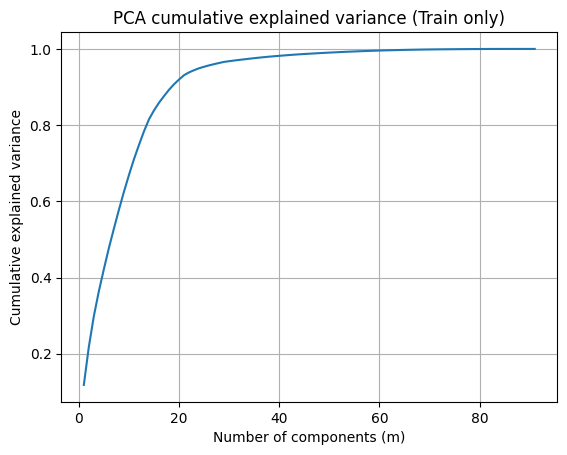

Chosen m for visualization: 2
Chosen m for ~95% variance: 25


In [ ]:
cum_evr = np.cumsum(evr)

plt.figure()
plt.plot(np.arange(1, len(cum_evr) + 1), cum_evr)
plt.xlabel("Number of components (m)")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance (Train only)")
plt.grid(True)
plt.show()

# Required: choose m in [2, n)
m_vis = 2
m_95 = int(np.searchsorted(cum_evr, 0.95) + 1)
m_95 = min(m_95, X_train.shape[1] - 1)  # ensure m < n

print("Chosen m for visualization:", m_vis)
print("Chosen m for ~95% variance:", m_95)


Project Train to 2D + plot by class

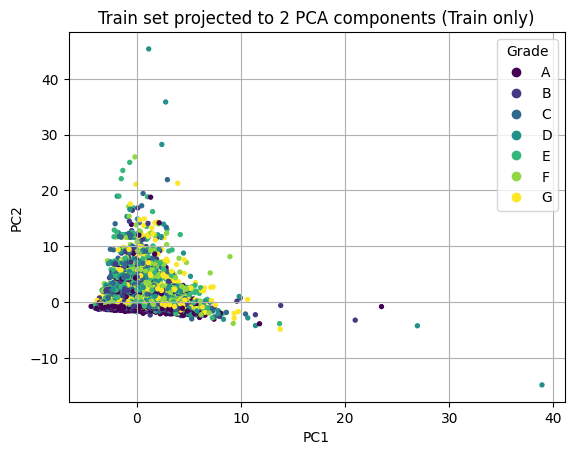

In [ ]:
Z_train_2 = pca_transform(X_train.to_numpy(), mu_pca, comps, m_vis)

grade_map = {0:"A", 1:"B", 2:"C", 3:"D", 4:"E", 5:"F", 6:"G"}

plt.figure()
sc = plt.scatter(Z_train_2[:, 0], Z_train_2[:, 1], c=y_train, s=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Train set projected to 2 PCA components (Train only)")
handles, _ = sc.legend_elements()
plt.legend(handles, [grade_map[i] for i in range(7)], title="Grade", loc="best")
plt.grid(True)
plt.show()


Show top contributing features for PC1/PC2

In [ ]:
#which original features most influence PC1 and PC2?

feature_names = np.array(X_train.columns)

def top_loadings(component_vector, k=15):
    idx_sorted = np.argsort(np.abs(component_vector))[::-1][:k]
    return list(zip(feature_names[idx_sorted], component_vector[idx_sorted]))

print("Top loadings for PC1:")
for name, val in top_loadings(comps[:, 0], k=15):
    print(f"{name:40s} {val:+.4f}")

print("\nTop loadings for PC2:")
for name, val in top_loadings(comps[:, 1], k=15):
    print(f"{name:40s} {val:+.4f}")


Top loadings for PC1:
total_acc                                +0.4775
open_acc                                 +0.4444
loan_amnt                                +0.3877
revol_bal                                +0.3280
credit_history_months                    +0.2923
term                                     +0.2542
annual_inc                               +0.2322
emp_length                               +0.1710
dti                                      +0.1501
inq_last_6mths                           +0.1205
home_ownership_MORTGAGE                  +0.1003
home_ownership_RENT                      -0.0971
revol_util                               +0.0923
delinq_2yrs                              +0.0883
verification_status_Verified             +0.0508

Top loadings for PC2:
pub_rec                                  +0.6662
pub_rec_bankruptcies                     +0.5092
tax_liens                                +0.4474
fico_avg                                 -0.2145
inq_last_6mths          

## PCA results (Train only)

In the original cleaned dataset we have **22 input features** (18 numeric + 4 categorical), plus the labels (`grade`, `grade_idx`).  
However, for PCA we first need everything to be numeric, so we **one-hot encoded** the categorical features. After this step, the training input matrix became **n = 91 features** .

We fit PCA **only on the Train set** and looked at the first two principal components (m = 2) for visualization.

From the **top loadings** (feature weights), we can interpret the components like this:

- **PC1** is mainly influenced by `total_acc`, `open_acc`, `loan_amnt`, `revol_bal`, and `credit_history_months` (also `term` and `annual_inc`).  
  So PC1 seems to capture an **overall “credit profile size / depth”** direction: more accounts, higher balances/loan amount, and longer credit history push points in the positive PC1 direction.

- **PC2** is dominated by `pub_rec`, `pub_rec_bankruptcies`, and `tax_liens`, while `fico_avg` has a negative loading.  
  This suggests PC2 captures a **“derogatory events vs good credit score”** direction: more public records/bankruptcies/liens push PC2 up, while higher FICO pushes it down.

Overall, PCA reduces the complexity of our features into a smaller set of meaningful directions, where PC1 relates to **credit depth/exposure** and PC2 relates to **negative credit events vs FICO**.


## PCA with m = 3 (3D projection)

So far we used **m = 2** to visualize the train set in 2D (PC1 vs PC2).  
Now we also try **m = 3**, which projects each example into **3 principal components**: (PC1, PC2, PC3).

PC3 captures additional variance that is **not explained by PC1 and PC2**, and is orthogonal to both.
This can sometimes reveal structure that is not visible in a 2D plot.


Transform to 3D + 3D scatter plot


Explained variance ratio:
 PC1: 0.1180702726903007
 PC2: 0.09981822047750842
 PC3: 0.08070531451086126
 Cumulative (PC1..PC3): 0.2985938076786704


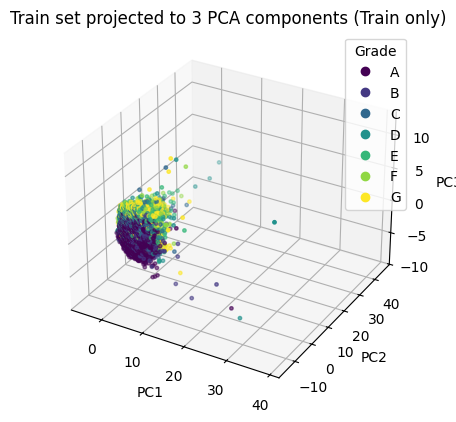

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

m_3d = 3
Z_train_3 = pca_transform(X_train.to_numpy(), mu_pca, comps, m_3d)

print("Explained variance ratio:")
print(" PC1:", evr[0])
print(" PC2:", evr[1])
print(" PC3:", evr[2])
print(" Cumulative (PC1..PC3):", evr[:3].sum())

grade_map = {0:"A", 1:"B", 2:"C", 3:"D", 4:"E", 5:"F", 6:"G"}

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(Z_train_3[:, 0], Z_train_3[:, 1], Z_train_3[:, 2], c=y_train, s=6)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Train set projected to 3 PCA components (Train only)")

# Legend
handles, _ = sc.legend_elements()
ax.legend(handles, [grade_map[i] for i in range(7)], title="Grade", loc="best")

plt.show()

In [ ]:
feature_names = np.array(X_train.columns)

def top_loadings(component_vector, k=15):
    idx_sorted = np.argsort(np.abs(component_vector))[::-1][:k]
    return list(zip(feature_names[idx_sorted], component_vector[idx_sorted]))

print("Top loadings for PC3:")
for name, val in top_loadings(comps[:, 2], k=15):
    print(f"{name:40s} {val:+.4f}")


Top loadings for PC3:
revol_util                               +0.6121
fico_avg                                 -0.5210
term                                     +0.3320
total_acc                                -0.2475
open_acc                                 -0.2444
loan_amnt                                +0.1798
credit_history_months                    -0.1724
dti                                      +0.1454
revol_bal                                +0.1041
verification_status_Not Verified         -0.0936
verification_status_Verified             +0.0825
annual_inc                               -0.0610
purpose_debt_consolidation               +0.0578
home_ownership_RENT                      +0.0380
pub_rec_bankruptcies                     -0.0328


## Interpretation of PC3 (Train-only PCA with m = 3)

When we move to **m = 3**, we introduce **PC3**, which captures variance not already covered by PC1 and PC2.

From the **largest PC3 loadings**, the main drivers are:
- `revol_util` (strong +): revolving credit utilization (% used)
- `fico_avg` (strong −): average FICO score (higher usually = lower risk)
- `term` (+): loan term (months)
- `total_acc`, `open_acc` (−): total and open credit accounts

So PC3 mostly behaves like a **utilization vs credit strength/depth** direction:
- Higher **`revol_util`** and longer **`term`** push PC3 **positive**
- Higher **`fico_avg`** and more established credit history (`total_acc`, `open_acc`) push PC3 **negative**

**Intuition:** high revolving utilization can reflect tighter finances and often lines up with higher risk, while higher FICO and a deeper credit profile usually signal lower risk.

Compared to earlier components, PC3 mainly separates borrowers by **how heavily they use revolving credit relative to their score and credit depth**.
